In [13]:
import pandas as pd
import numpy as np
import re
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

import joblib
import os

In [14]:
ev2 = pd.read_csv('../../Datasets/evaluacion2.csv')
ev2.head(1)

,product_title,product_rating,is_best_seller,is_sponsored,buy_box_availability,sustainability_tags,has_coupon,discount_percentage,product_category,product_segment,log_original_price,log_purchased_last_month,log_total_reviews
0,OWC 2.0TB Aura Pro X2 (GEN 4) SSD Complete Upg...,4.4,No Badge,Sponsored,1,0,0,0.0,PC Components,Media,5.484755,0.0,5.883322


In [26]:
ev2['product_category'].value_counts()

product_category
Office Supplies, Ink & Toner                     1107
Computer Peripherals                              757
Audio, Sound & Recording Gear                     721
PC Components                                     646
Small Gadget Accessories (Cases & Protectors)     594
TV & Video Displays                               588
Chargers, Adapters & Cables                       489
Laptops                                           475
Wearables                                         427
Cameras & Photography                             413
Storage & Memory Cards                            311
Power & Batteries                                 272
Networking                                        177
Smart Home & Security                             172
Printers & Scanners (Hardware)                    163
Mobile Cell Phones & Smartphones                  142
Other Electronics                                 131
Tablets & E-readers (DEVICES ONLY)                 83
Video Game 

In [16]:
# 1. Definimos una lista de "Palabras que parecen marcas pero son ruido"
blacklist = ['EZ', 'THE', 'AND', 'FOR', 'PRO', 'NEW', 'OFF']

# 2. Tu proceso de extracción
ev2['brand'] = ev2['product_title'].str.split().str[0].str.upper().str.replace(r'[^A-Z0-9]', '', regex=True)

# 3. FILTRO DE CALIDAD:
# Enviamos a OTHER si:
# - Está en la blacklist
# - Es un número puro (ej: "100")
# - Es demasiado corto (menos de 2 caracteres, excepto marcas como LG)
def clean_brand(b):
    if b in blacklist: return 'OTHER'
    if b.isdigit(): return 'OTHER' 
    if len(b) < 2: return 'OTHER'
    return b

ev2['brand'] = ev2['brand'].apply(clean_brand)

# 4. RE-CALCULAR EL TOP 50
# Tip: Si quieres que GIGABYTE sea 'OTHER' podrías sacarla del conteo manualmente
top_brands = ev2[ev2['brand'] != 'OTHER']['brand'].value_counts().nlargest(100).index

ev2['brand_cat'] = ev2['brand'].apply(lambda x: x if x in top_brands else 'OTHER')
ev2.drop(columns=['brand'], inplace=True)

In [17]:
# 2. BOOLEAN FEATURES (Regex)
# si es un modelo de alta gama
ev2['is_high_end'] = ev2['product_title'].str.contains(r'\b(Pro|Ultra|Gaming|Business|Elite|Max|Plus|Enterprise)\b', case=False, regex=True).astype(int)

C:\Users\diego\AppData\Local\Temp\ipykernel_22896\984869603.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ev2['is_high_end'] = ev2['product_title'].str.contains(r'\b(Pro|Ultra|Gaming|Business|Elite|Max|Plus|Enterprise)\b', case=False, regex=True).astype(int)


In [18]:
def extraer_resolucion(title):
    title = str(title).lower()
    
    # 1. NIVEL TOP (8K, 5K - Muy caros)
    if re.search(r'\b(8k|5k)\b', title):
        return '8K_5K_Ultra'
        
    # 2. NIVEL ALTO (4K, UHD, Retina - Apple y Gama Alta)
    # "Retina" es clave para Apple, que no suele decir "4K" pero es caro.
    if re.search(r'\b(4k|uhd|2160p|ultra hd|retina)\b', title):
        return '4K_UHD_Retina'
        
    # 3. NIVEL MEDIO-ALTO (2K, QHD, 1440p - Gaming y Oficina Pro)
    if re.search(r'\b(2k|qhd|wqhd|1440p)\b', title):
        return '2K_QHD'
        
    # 4. NIVEL ESTÁNDAR (Full HD, 1080p - El estándar hoy en día)
    if re.search(r'\b(1080p|fhd|full hd|1920x1080)\b', title):
        return 'FHD_1080p'
        
    # 5. NIVEL BÁSICO (HD, 720p - Laptops baratos y TVs pequeñas)
    if re.search(r'\b(720p|hd|1366x768)\b', title):
        return 'HD_Basic'
        
    # Si no especifica nada (NaN para que XGBoost decida)
    return np.nan

In [19]:
def extractor_maestro(df):
    # Creamos copias para no tocar el original
    df_new = df.copy()
    
    # 1. Definimos las nuevas columnas vacías (NaN)
    specs = ['spec_ram_gb', 'spec_storage_gb', 'spec_screen_inch', 
    'spec_power_w', 'spec_pack_count', 'spec_resolution_cat',
    'spec_refresh_rate_hz', 'spec_ram_speed_mhz']
    for col in specs:
        df_new[col] = np.nan

    # 2. Lógica de Extracción Fila a Fila
    for i, row in df_new.iterrows():
        title = str(row['product_title']).lower()
        cat = str(row['product_category'])
        
        # --- BLOQUE A: RAM (Solo para Ordenadores/Tablets) ---
        if cat in ['Laptops', 'PC Components', 'Tablets & E-readers (DEVICES ONLY)', 'Computer Peripherals']:
            
            # EXPLICACIÓN REGEX RAM:
            # 1. (\d+)\s*(?:gb|g) -> Coge numero y unidad
            # 2. Grupo de Ruido con LOOKAHEAD NEGATIVO (?!) -> Acepta palabras intermedias SOLO SI:
            #    a) NO son 'ssd', 'hdd', 'storage', 'rom' (Evita coger discos)
            #    b) NO son 'd+ gb' (Evita coger otra capacidad que aparezca después)
            
            regex_ram = r'(\d+)\s*(?:gb|g)\s*(?:(?!(?:ssd|hdd|storage|rom)|\d+\s*(?:gb|g))[\w\-\.\(\)]+\s*){0,3}?(?:ram|memory|ddr|unified|vram|gddr)|(?:ram|memory|ddr\d?|capacity|vram|gddr\d?)\s*(?:kit)?\s*(\d+)\s*(?:gb|g)'
            
            match = re.search(regex_ram, title)
            if match:
                val = next((m for m in match.groups() if m is not None), None)
                if val: df_new.at[i, 'spec_ram_gb'] = float(val)
                
        # --- BLOQUE B: ALMACENAMIENTO (Ordenadores, Discos, Móviles) ---
        target_cats_storage = ['Laptops', 'PC Components', 'Storage & Memory Cards', 'Mobile Cell Phones & Smartphones', 'Tablets & E-readers (DEVICES ONLY)']
        if cat in target_cats_storage:
            
            # CAMBIO CLAVE EN EL REGEX:
            # Antes: (?!gb|tb|to) -> Solo miraba si empezaba por letras de unidad.
            # Ahora: (?!\d+\s*(?:gb|tb|to)) -> Mira si es un NÚMERO seguido de unidad.
            # Esto impide que "512GB" sea tratado como ruido.
            
            regex_storage = r'(\d+)\s*(gb|tb|to)\s*(?:(?!\d+\s*(?:gb|tb|to))[\w\-\.]+\s*){0,3}?(?:ssd|hdd|storage|flash|rom|emmc|hard drive|disk)'
            
            match = re.search(regex_storage, title)
            
            # Fallback para tarjetas de memoria
            if not match and cat == 'Storage & Memory Cards':
                match = re.search(r'(\d+)\s*(gb|tb|to)', title)
            
            if match:
                val = float(match.group(1))
                unit = match.group(2)
                
                if unit in ['tb', 'to']:
                    val *= 1024
                
                df_new.at[i, 'spec_storage_gb'] = val

        # C. PANTALLA Y RESOLUCIÓN (Visuales)
        if cat in ['Laptops', 'TV & Video Displays', 'Monitors', 'Tablets & E-readers (DEVICES ONLY)', 'Mobile Cell Phones & Smartphones', 'Office Supplies, Ink & Toner']:
            # Pulgadas
            match = re.search(r'(\d+(?:\.\d+)?)\s*(?:\"|inch|”|\-inch)', title)
            if match: df_new.at[i, 'spec_screen_inch'] = float(match.group(1))
            
            # Resolución (Nueva Lógica)
            res = extraer_resolucion(title)
            if pd.notna(res): df_new.at[i, 'spec_resolution_cat'] = res

        # --- BLOQUE D: POTENCIA (Cargadores, Audio, Componentes) ---
        if cat in ['Chargers, Adapters & Cables', 'Power & Batteries', 'Audio, Sound & Recording Gear', 'PC Components', 'Computer Peripherals']:
            # \b significa "Word Boundary" (Límite de palabra). 
            # Esto evita que 'Wireless', 'White', 'Warranty' o 'With' cuenten como 'W'.
            
            # Busca: Numero + (W o Watt o Vatios) + FINAL DE PALABRA
            match = re.search(r'(\d+)\s*(?:w|watt|vatios)\b', title)
            
            if match:
                df_new.at[i, 'spec_power_w'] = float(match.group(1))

        # --- BLOQUE E: PACKS (Oficina, Cables, Pilas) ---
        if cat in ['Office Supplies, Ink & Toner', 'Small Gadget Accessories (Cases & Protectors)', 
                   'Chargers, Adapters & Cables', 'Power & Batteries', 'Cameras & Photography', 
                   'Computer Peripherals', 'Other Electronics']:
            
            # 1. Patrón Estándar: "Pack of 2", "Set of 5"
            match = re.search(r'(?:pack of|set of|count of)\s*(\d+)', title)
            
            # 2. Patrón Inverso: "2-Pack", "10 count", "50 sheets", "2 pieces", "4 cartridges"
            # AÑADIDO: 'cartridges' a la lista de palabras clave
            if not match: 
                match = re.search(r'(\d+)\s*[-]?\s*(?:pack|set|count|pcs|sheets|pieces|cartridges)', title)
            
            # 3. Patrón Tinta Entre Paréntesis (CASO ESPECÍFICO PGBK)
            # Detecta: "(2 PGBK)", "(4 BK)", "(2 Black)", "(5 Cartridges)"
            # La clave son los paréntesis \(\) para no confundir con modelos (ej: Canon 280)
            if not match and cat == 'Office Supplies, Ink & Toner':
                match = re.search(r'\(\s*(\d+)\s*(?:pgbk|bk|c|m|y|black|cyan|magenta|yellow|color|ink)\b', title)

            if match:
                df_new.at[i, 'spec_pack_count'] = float(match.group(1))
            
            # 4. Caso especial Pair/Twin
            elif 'pair' in title or 'twin pack' in title: 
                df_new.at[i, 'spec_pack_count'] = 2.0
                
        # Buscamos Hz altos (90, 120, 144, 165, 240, 360, etc.)
        if cat in ['Laptops', 'TV & Video Displays', 'Monitors', 'Tablets & E-readers (DEVICES ONLY)', 'Mobile Cell Phones & Smartphones']:
            # Regex: Número + Hz (con boundary \b para no coger cosas raras)
            match_hz = re.search(r'(\d+)\s*hz\b', title)
            if match_hz:
                hz_val = float(match_hz.group(1))
                # FILTRO DE SEGURIDAD:
                # Ignoramos 50Hz o 60Hz si es una TV barata o Laptop, ya que es el estándar y a veces se confunde con el input eléctrico.
                # Nos interesan los valores "Gaming" que suben el precio.
                # O bien, lo guardamos todo y dejamos que XGBoost decida. Yo recomiendo guardarlo todo.
                df_new.at[i, 'spec_refresh_rate_hz'] = hz_val

        # 2. VELOCIDAD RAM (PC Components, Laptops)
        # Buscamos MHz (2666, 3200, 5200, 6000...)
        if cat in ['PC Components', 'Laptops', 'Computer Peripherals']:
            
            # Regex: Número + (mhz O mt/s O mts)
            # (?i) al principio hace que sea case-insensitive (aunque ya pasamos title.lower())
            match_speed = re.search(r'(\d+)\s*(?:mhz|mt/s|mts)\b', title)
            
            if match_speed:
                val = float(match_speed.group(1))
                
                # FILTRO ANTI-RUIDO:
                # A veces coge "2.4 ghz" (wifi) como 2 (mhz). 
                # Las RAMs modernas suelen ser de más de 1000 MHz.
                # Las viejas DDR2 eran 400-800. 
                # Vamos a poner un suelo de 200 para evitar coger frecuencias de radio o wifi mal escritas.
                if val > 200:
                    df_new.at[i, 'spec_ram_speed_mhz'] = val
        

    return df_new

In [20]:
ev2_specs = extractor_maestro(ev2)

C:\Users\diego\AppData\Local\Temp\ipykernel_22896\4213627003.py:67: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'HD_Basic' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  if pd.notna(res): df_new.at[i, 'spec_resolution_cat'] = res


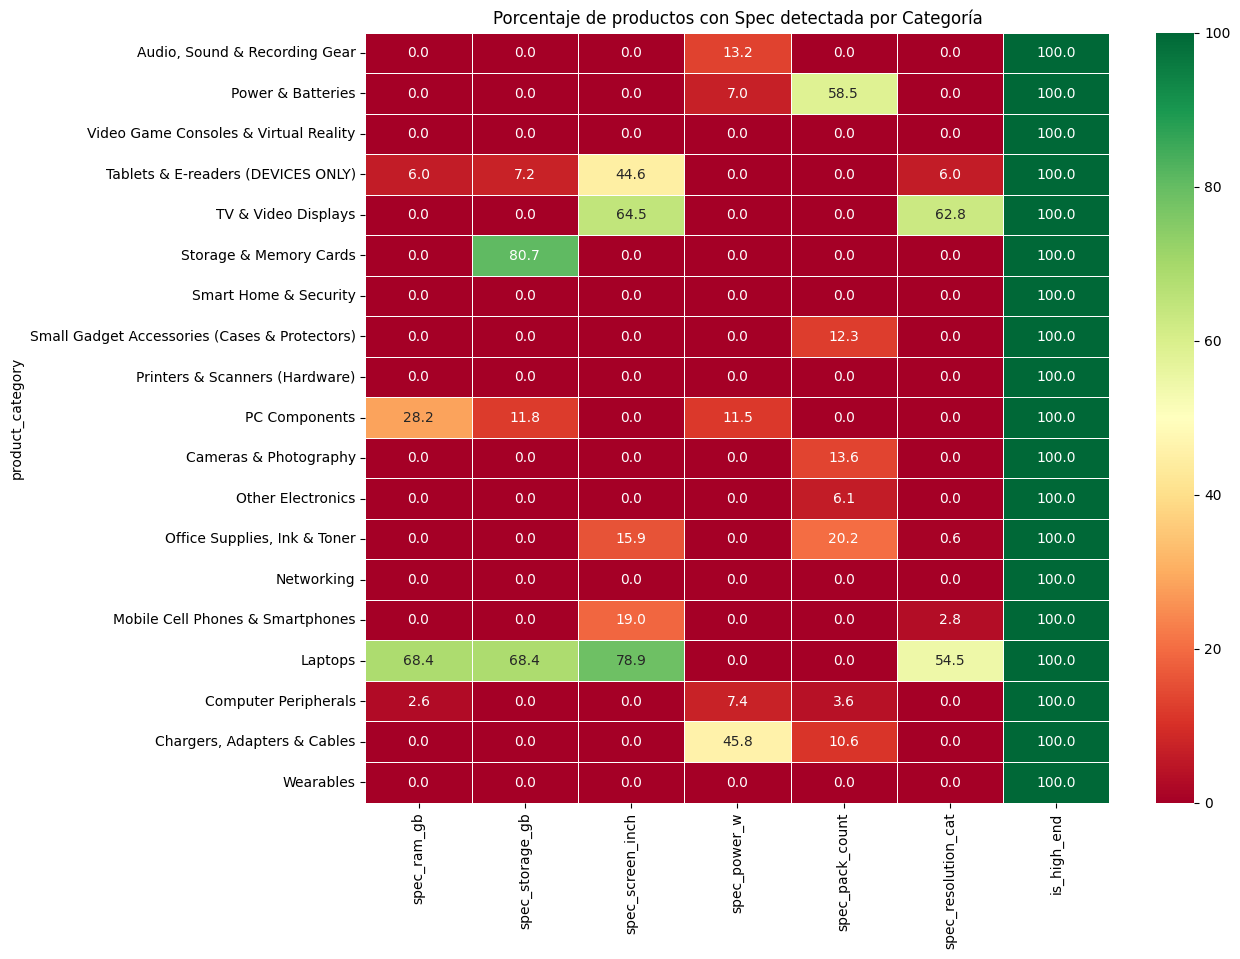

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definimos las columnas que queremos auditar
specs_cols = [
    'spec_ram_gb', 'spec_storage_gb', 'spec_screen_inch', 
    'spec_power_w', 'spec_pack_count', 'spec_resolution_cat',
    'is_high_end' # Esta siempre es 0 o 1, pero veamos si hay variación
]

# 2. Creamos la tabla de conteo (¿Cuántos datos NO son nulos?)
# Asumimos que tu dataframe se llama 'df_ready' o 'df_final'
# Asegúrate de que los nulos sean np.nan o None, no ceros (si 0 significa "sin dato")
audit = ev2_specs.groupby('product_category')[specs_cols].count()

# 3. Añadimos el total de productos por categoría para tener contexto
audit['TOTAL_PRODUCTS'] = ev2_specs['product_category'].value_counts()

# 4. Calculamos el PORCENTAJE de cobertura (Más fácil de leer)
audit_pct = (audit.div(audit['TOTAL_PRODUCTS'], axis=0) * 100).round(1)

# Reordenamos para que TOTAL esté primero
cols = ['TOTAL_PRODUCTS'] + [c for c in audit_pct.columns if c != 'TOTAL_PRODUCTS']
audit_pct = audit_pct[cols].sort_values('TOTAL_PRODUCTS', ascending=False)


# Opción Gráfica (Heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(audit_pct.drop(columns=['TOTAL_PRODUCTS']), annot=True, fmt='.1f', cmap='RdYlGn', linewidths=.5)
plt.title("Porcentaje de productos con Spec detectada por Categoría")
plt.show()


In [25]:
# 1. Cargar el modelo de Embeddings
print("Cargando modelo de Sentence Transformers...")
model_ecom = SentenceTransformer('wjunwei/ecommerce_text_embedding')

# 2. Generar Embeddings
print("Generando embeddings de los títulos...")
# Convertimos a lista para el modelo
titles = ev2_specs['product_title'].astype(str).tolist()
embeddings = model_ecom.encode(titles, batch_size=32, show_progress_bar=True)

# 3. Reducción de dimensionalidad (PCA de 50 componentes)
# Usamos PCA en lugar de SVD porque los embeddings suelen estar centrados
n_components_emb = 50
pca_emb = PCA(n_components=n_components_emb, random_state=42)
compressed_embeddings = pca_emb.fit_transform(embeddings)

# ==============================================================================
# GUARDAR ARCHIVOS PKL
# ==============================================================================
folder_path = 'Archivos_modelos'
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    
# El modelo de SentenceTransformer NO se guarda con Joblib habitualmente (se descarga),
# pero el PCA es CRÍTICO guardarlo para poder transformar nuevos productos.
pca_path = os.path.join(folder_path, f'pca_embeddings_model_{n_components_emb}.pkl')
joblib.dump(pca_emb, pca_path)

print(f"✅ Archivo '{pca_path}' guardado.")
# ==============================================================================

# 4. Añadimos al DF
emb_cols = [f'emb_{i}' for i in range(n_components_emb)]
df_emb = pd.DataFrame(compressed_embeddings, columns=emb_cols, index=ev2_specs.index)
df_final = pd.concat([ev2_specs, df_emb], axis=1)

# ==============================================================================
# 4. PREPARING FINAL DATAFRAME FOR XGBOOST
# ==============================================================================
# Actualizamos la lista de columnas con las nuevas emb_x
cols_to_keep = [
    'product_title','product_rating', 'log_total_reviews', 'log_purchased_last_month', 
    'is_sponsored', 'buy_box_availability', 'has_coupon', 'discount_percentage', 
    'product_category', 'brand_cat', 'is_high_end', 'spec_ram_gb', 'spec_storage_gb',
    'spec_screen_inch', 'spec_power_w', 'spec_pack_count', 'spec_resolution_cat', 
    'spec_refresh_rate_hz', 'spec_ram_speed_mhz', 'log_original_price', 'is_best_seller'
] + emb_cols

df_engineered = df_final[cols_to_keep].copy()

# Convertir tipos categóricos
for col in ['product_category', 'brand_cat', 'spec_resolution_cat', 'is_best_seller']:
    if col in df_engineered.columns:
        df_engineered[col] = df_engineered[col].astype('category')

# Guardar a CSV
output_csv = f'../../Datasets/amazon_wjunwei_{n_components_emb}.csv'
df_engineered.to_csv(output_csv, index=False)

print(f"✅ Dataset con Embeddings guardado en: {output_csv}")
print(f"Dimensiones finales: {df_engineered.shape}")

Cargando modelo de Sentence Transformers...


d:\Documentos\diego\Master\Amazon-Smart-Pricing\.venv\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Generando embeddings de los títulos...


Batches:   0%|          | 0/242 [00:00<?, ?it/s]

✅ Archivo 'Archivos_modelos\pca_embeddings_model_50.pkl' guardado.
✅ Dataset con Embeddings guardado en: ../../Datasets/amazon_wjunwei_50.csv
Dimensiones finales: (7717, 71)
